# **Programa Especializado en Credit Scoring con Python**
<img src="../../figuras/logo.png" width="200"/>

## 📊 **Sesión 13: Comparación y Selección de Modelos.**

**Docente**: Enzo Infantes Zúñiga  
**Contacto**: <enzo.infantes28@gmail.com>  
**LinkedIn**: [enzo-infantes](https://www.linkedin.com/in/enzo-infantes/)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ptitprince as pt
import seaborn as sns
import math
import sys
import os
import joblib
import warnings
from scipy.stats import randint, uniform

from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import (RandomizedSearchCV, GridSearchCV, StratifiedKFold, cross_val_score, learning_curve, cross_validate)
from sklearn.metrics import (roc_auc_score, roc_curve, auc, confusion_matrix, classification_report, ConfusionMatrixDisplay, average_precision_score, log_loss)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

absolute_path = os.path.dirname(os.path.dirname(os.getcwd()))
data_path = os.path.join(absolute_path, "data", "s10")
src_path = os.path.join(absolute_path, "src", "s12")
model_path = os.path.join(absolute_path, "models")
figure_path = os.path.join(absolute_path, "figuras", "s13")
sys.path.insert(0, src_path)

SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

from evaluation import Evaluation

🎯 **Objetivos de la sesión**

Comparar los 4 modelos candidatos (+ Logistic Regression como baseline), seleccionar el modelo final y justificar la decisión en términos de riesgo de crédito.

📌 **Agenda**

| # | Sección | Descripción |
|---|---------|-------------|
| 0 | Setup | Librerías, datos, carga de modelos |
| 1 | Baseline | Logistic Regression como punto de referencia |
| 2 | Discriminación | AUC-ROC, Gini, KS, Curva PR |
| 3 | Calibración | Brier Score, Hosmer-Lemeshow, Reliability Diagram |
| 4 | Análisis Económico | Curvas de Ganancia, Lift, Cost-Benefit |
| 5 | Estabilidad | CV estratificada, PSI, Overfitting |
| 6 | Dashboard | Tabla consolidada + Radar Chart |
| 7 | Selección Final | Score ponderado + justificación regulatoria |
| 8 | Conclusiones | Recomendaciones y próximos pasos |

# **1. Carga de Datos**

### 1.1 Dataset Simulado de Crédito

In [2]:
X_train = pd.read_csv(os.path.join(data_path, 'X_train_proc.csv'))
X_test  = pd.read_csv(os.path.join(data_path, 'X_test_proc.csv'))
X_val   = pd.read_csv(os.path.join(data_path, 'X_val_proc.csv'))
y_train = pd.read_csv(os.path.join(data_path, 'y_train.csv'))
y_test  = pd.read_csv(os.path.join(data_path, 'y_test.csv'))
y_val   = pd.read_csv(os.path.join(data_path, 'y_val.csv'))

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"X_val shape: {X_val.shape}")

print(f"y_train defaul rate: {y_train['DEFAULT'].mean()*100:.2f}")
print(f"y_test defaul rate: {y_test['DEFAULT'].mean()*100:.2f}")
print(f"y_val defaul rate: {y_val['DEFAULT'].mean()*100:.2f}")

X_train shape: (17341, 24)
X_test shape: (7875, 24)
X_val shape: (4784, 24)
y_train defaul rate: 22.38
y_test defaul rate: 22.60
y_val defaul rate: 22.49


In [3]:
X_train.set_index("MES_STR", inplace=True)
X_test.set_index("MES_STR", inplace=True)
X_val.set_index("MES_STR", inplace=True)

# **2. Cargando Modelos**

In [4]:
model_dt  = joblib.load(os.path.join(model_path, 's11', 'modelo_dt_optimizado.pkl'))
model_rf  = joblib.load(os.path.join(model_path, 's11', 'modelo_rf_optimizado.pkl'))
model_xgb = joblib.load(os.path.join(model_path, 's12', 'modelo_xgb.pkl'))
model_lgb = joblib.load(os.path.join(model_path, 's12', 'modelo_lgb.pkl'))

print("Modelos cargados: Decision Tree, Random Forest, XGBoost, LightGBM")

Modelos cargados: Decision Tree, Random Forest, XGBoost, LightGBM


# **3. Baseline - Logistic Regression**

La Regresión Logística es el modelo estándar de la industria bancaria para credit scoring
(Siddiqi, 2006; Thomas et al., 2002). Usarla como **baseline** permite responder:

> *¿Cuánta ganancia real aportan los modelos de ML respecto al modelo regulatorio estándar?*

Esto es clave para justificar complejidad adicional ante un supervisor (BIS BCBS, 2005).

In [5]:
# ── Regresión Logística ──────────────────────────────
param_dist_lr = {
    'C': uniform(0.01, 10), 
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] 
}

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

lr_search = RandomizedSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        class_weight='balanced', # Equivalente conceptual a scale_pos_weight
        random_state=SEED
    ),
    param_distributions=param_dist_lr,
    n_iter=30,
    scoring='roc_auc',
    cv=cv_strat,
    random_state=SEED,
    n_jobs=-1,
    verbose=0
)

lr_search.fit(X_train, y_train)
lr_tuned = lr_search.best_estimator_

print("Mejores hiperparámetros encontrados (LR):")
for k, v in lr_search.best_params_.items():
    print(f"  {k:<22}: {v:.4f}" if isinstance(v, float) else f"  {k:<22}: {v}")

print(f"\nAUC CV (best baseline): {lr_search.best_score_:.4f}")

Mejores hiperparámetros encontrados (LR):
  C                     : 8.3344
  penalty               : l2
  solver                : liblinear

AUC CV (best baseline): 0.7812



── Test Set Metrics (OOT)  —  threshold = 0.4805 ────────
  ROC AUC          : 0.7817
  PR AUC           : 0.5465
  Recall           : 0.7185
  Precision        : 0.4098
  F1 Score         : 0.5219

              precision    recall  f1-score   support

    Good (0)       0.89      0.70      0.78      6095
     Bad (1)       0.41      0.72      0.52      1780

    accuracy                           0.70      7875
   macro avg       0.65      0.71      0.65      7875
weighted avg       0.79      0.70      0.72      7875



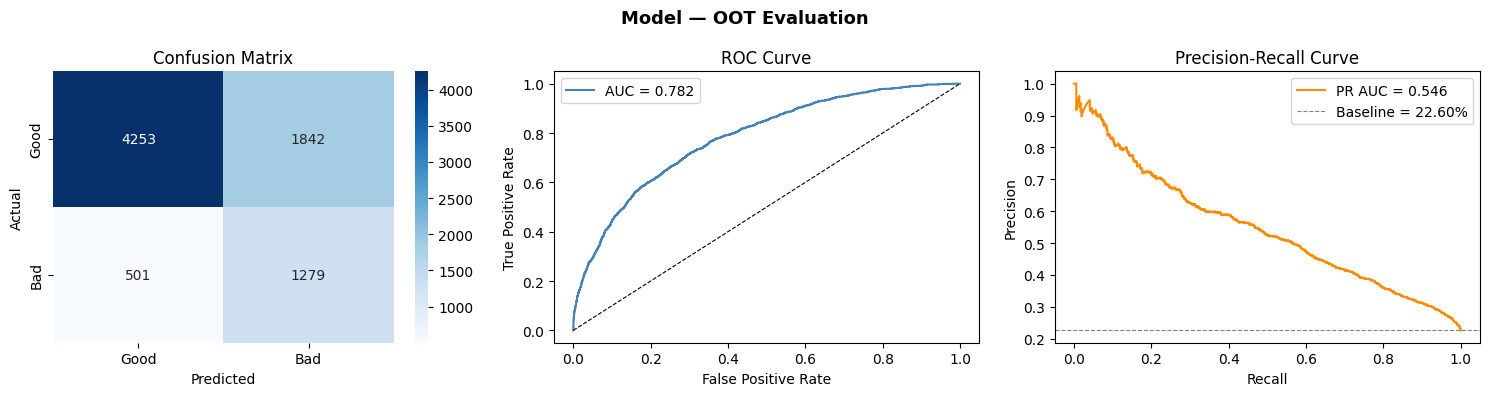

[plot]  Saved → '../../figuras/s12/evaluation.png'
[plot_feature_importance] Model 'LogisticRegression' not supported.

✅  Evaluation completed.


In [6]:
features = X_train.columns.tolist() 

eval_lr_val = Evaluation(
    model=lr_tuned,
    x=X_test,
    y=y_test,
    features=features
)

eval_lr_val.run_all()

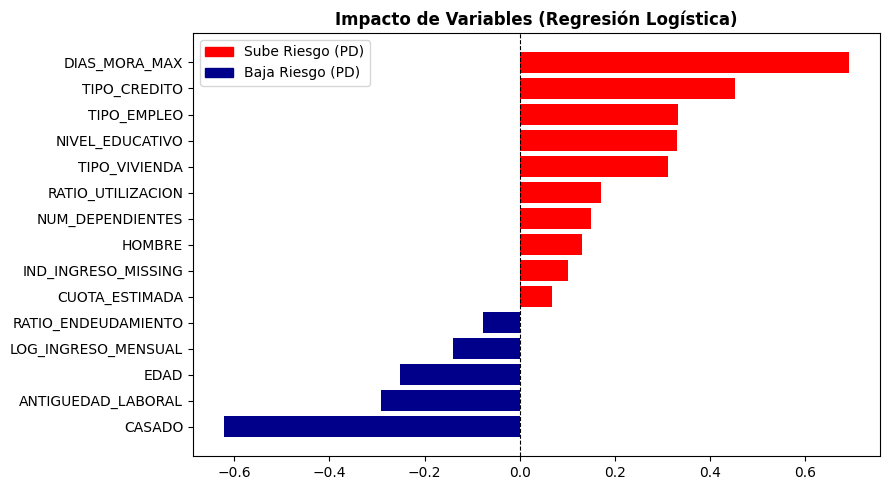

In [7]:
df_coefs = pd.DataFrame({'Variable': features, 'Coeficiente': lr_tuned.coef_[0]})
top_15 = df_coefs.reindex(df_coefs['Coeficiente'].abs().nlargest(15).index).sort_values('Coeficiente')

plt.figure(figsize=(9, 5))
colores = ['red' if c > 0 else 'darkblue' for c in top_15['Coeficiente']]
plt.barh(top_15['Variable'], top_15['Coeficiente'], color=colores)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Impacto de Variables (Regresión Logística)', fontweight='bold')
plt.legend(handles=[mpatches.Patch(color = 'red', label='Sube Riesgo (PD)'), 
                    mpatches.Patch(color= 'darkblue', label='Baja Riesgo (PD)')])

plt.tight_layout()
plt.savefig('../../figuras/s13/coeficientes_logistic_regression.png', dpi=150)
plt.show()

In [8]:
joblib.dump(lr_tuned, os.path.join(model_path, 's13','modelo_lr.pkl'))
model_lr = joblib.load(os.path.join(model_path, 's13', 'modelo_lr.pkl'))

# **3. Métricas de Discriminación**

Las métricas de discriminación evalúan **qué tan bien el modelo separa buenos de malos pagadores**.
Son las más utilizadas en la práctica bancaria y en guías regulatorias.

| Métrica | Interpretación en Credit Scoring | Umbral Referencial |
|---------|----------------------------------|--------------------|
| **AUC-ROC** | Prob. de que un malo score > que un bueno | > 0.75 aceptable, > 0.80 bueno |
| **Gini** | = 2·AUC - 1; el más usado en scoring bancario | > 0.50 aceptable |
| **KS** | Máxima separación acumulada entre buenos y malos | > 0.40 aceptable |
| **PR-AUC** | AUC de curva Precisión-Recall; mejor con desbalance | Depende del contexto |

> **Referencia:** Siddiqi (2006, Cap. 10); Lessmann et al. (2015, EJOR 247(1)).

In [9]:
# ── Funciones Auxiliares ─────────────────────────────────────────────────────
def compute_ks(y_true, y_proba):
    """Kolmogorov-Smirnov: máxima diferencia entre Función de Distribución Acumulada de buenos y malos."""
    df = pd.DataFrame({'y': np.array(y_true).ravel(), 'p': np.array(y_proba).ravel()})
    df = df.sort_values('p', ascending=False).reset_index(drop=True)
    n_bad  = df['y'].sum()
    n_good = len(df) - n_bad
    df['cum_bad']  = df['y'].cumsum() / n_bad # cum_bad: ¿Qué % del total de malos hemos capturado hasta esta fila?
    df['cum_good'] = (1 - df['y']).cumsum() / n_good # cum_good: ¿Qué % del total de buenos hemos "castigado" injustamente hasta esta fila?
    df['ks']       = (df['cum_bad'] - df['cum_good']).abs() # Queremos que la curva de malos suba muy rápido y la de buenos muy lento.
    return df['ks'].max()

def compute_gini(y_true, y_proba):
    """Gini = 2 * AUC - 1."""
    return 2 * roc_auc_score(y_true, y_proba) - 1

MODELS = {
    'Logistic Reg (Baseline)': (model_lr,  'blue'),
    'Decision Tree'           : (model_dt,  'orange'),
    'Random Forest'           : (model_rf,  'green'),
    'XGBoost'                 : (model_xgb, 'red'),
    'LightGBM'                : (model_lgb, 'purple'),
}

PROBAS = {
    name: model.predict_proba(X_test)[:, 1]
    for name, (model, _) in MODELS.items()
}

print("Funciones y diccionario de modelos listos")

Funciones y diccionario de modelos listos


In [10]:
rows = []
for name, proba in PROBAS.items():
    rows.append({
        'Modelo'  : name,
        'AUC-ROC' : round(roc_auc_score(y_test, proba), 4),
        'Gini'    : round(compute_gini(y_test, proba), 4),
        'KS'      : round(compute_ks(y_test, proba), 4),
        'PR-AUC'  : round(average_precision_score(y_test, proba), 4),
        'Log-Loss': round(log_loss(y_test, proba), 4),
    })

metrics_df = pd.DataFrame(rows).set_index('Modelo')
print("\n Métricas de Discriminación — Conjunto de Test\n")
print(metrics_df.to_string())


 Métricas de Discriminación — Conjunto de Test

                         AUC-ROC    Gini      KS  PR-AUC  Log-Loss
Modelo                                                            
Logistic Reg (Baseline)   0.7817  0.5635  0.4163  0.5465    0.5526
Decision Tree             0.7352  0.4703  0.3459  0.4539    0.5965
Random Forest             0.7676  0.5353  0.3988  0.5150    0.5605
XGBoost                   0.7787  0.5573  0.4191  0.5386    0.5536
LightGBM                  0.7756  0.5512  0.4143  0.5348    0.5484


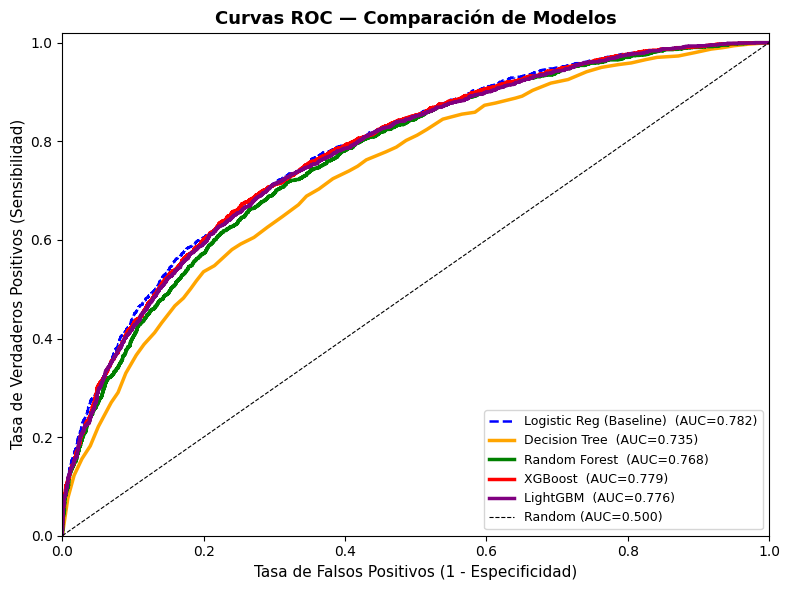

In [11]:
# ── Curvas ROC ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for (name, (_, color)), proba in zip(MODELS.items(), PROBAS.values()):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc_val = auc(fpr, tpr)
    lw = 1.8 if 'Baseline' in name else 2.5
    ls = '--'  if 'Baseline' in name else '-'
    ax.plot(fpr, tpr, color=color, lw=lw, ls=ls,
            label=f'{name}  (AUC={roc_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random (AUC=0.500)')
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
ax.set_title('Curvas ROC — Comparación de Modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('../../figuras/s13/sesion13_roc_curves.png', dpi=150)
plt.show()

# **4. Estabilidad y Robustez**

Un buen AUC en test **no garantiza performance estable en el tiempo**.
La estabilidad es un requisito explícito en:
- Basilea II/III (BCBS, 2006): *"Models must perform consistently over time"*
- EBA Guidelines (2017): PSI < 0.10 para aprobación de modelo

| Indicador | Descripción | Umbral |
|-----------|-------------|--------|
| **CV Score (std)** | Varianza del AUC en validación cruzada | Std < 0.02 |
| **PSI** | Population Stability Index entre train y test | < 0.10 estable, < 0.25 monitorear |
| **Overfitting Ratio** | AUC_train / AUC_test | < 1.05 aceptable |

> "A PSI value of 0 implies the observed and expected distributions are identical with the PSI increasing in value as the two distributions diverge. (...) less than 10% show no significant change; values between 10% and 25% show a small change requiring investigation; and values greater than 25% show a significant change."  (Taplin & Hunt, 2019, p. 4).

In [12]:
# ── Validación Cruzada 5-Fold Estratificada ──────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_full = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

cv_rows = []
for name, (model, _) in MODELS.items():
    res = cross_validate(model, X_full, y_full, cv=cv,
                         scoring='roc_auc', return_train_score=True)
    mean_test  = res['test_score'].mean()
    std_test   = res['test_score'].std()
    mean_train = res['train_score'].mean()
    overfit    = mean_train / (mean_test + 1e-9)
    cv_rows.append({
        'Modelo'           : name,
        'AUC CV (mean)'    : round(mean_test, 4),
        'AUC CV (std)'     : round(std_test, 4),
        'AUC Train'        : round(mean_train, 4),
        'Overfitting Ratio': round(overfit, 3),
    })

cv_df = pd.DataFrame(cv_rows).set_index('Modelo')
print("\n🔄 Validación Cruzada 5-Fold Estratificada:\n")
print(cv_df.to_string())


🔄 Validación Cruzada 5-Fold Estratificada:

                         AUC CV (mean)  AUC CV (std)  AUC Train  Overfitting Ratio
Modelo                                                                            
Logistic Reg (Baseline)         0.7816        0.0057     0.7835              1.002
Decision Tree                   0.7343        0.0081     0.7657              1.043
Random Forest                   0.7664        0.0077     0.8131              1.061
XGBoost                         0.7778        0.0069     0.8014              1.030
LightGBM                        0.7748        0.0063     0.8259              1.066


In [13]:
PSI_GREEN  = 0.10
PSI_YELLOW = 0.25
N_BINS_PSI = 10

def compute_psi(expected, actual, n_bins=N_BINS_PSI):
    """
    PSI = Σ (Actual% - Expected%) × ln(Actual% / Expected%)
    Mide qué tanto ha cambiado la distribución de los scores entre Train y Test.
    """
    # 1. Crear los cortes (bins) basados en la distribución de Train (Expected)
    _, bin_edges = np.histogram(expected, bins=n_bins)
    bin_edges[0]  = -np.inf # Asegura capturar valores mínimos
    bin_edges[-1] =  np.inf # Asegura capturar valores máximos

    # 2. Calcular porcentajes por bin, evitando ceros con .clip
    exp_pct = (np.histogram(expected, bins=bin_edges)[0] / len(expected)).clip(min=1e-9) 
    act_pct = (np.histogram(actual,   bins=bin_edges)[0] / len(actual)  ).clip(min=1e-9)
    
    # 3. Fórmula del PSI
    psi_val = np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))
    return float(psi_val)

def psi_label(psi):
    """Devuelve un estado visual basado en los umbrales estándar de la industria."""
    if psi < PSI_GREEN:  return 'Stable'
    if psi < PSI_YELLOW: return 'Monitor'
    return 'Investigate'

# ── Ejecución para todos los modelos ─────────────────────────────────────────
psi_rows = []

for name, (model, _) in MODELS.items():

    train_sc = model.predict_proba(X_train)[:, 1]
    test_sc  = model.predict_proba(X_test)[:, 1]
    
    psi_val = compute_psi(train_sc, test_sc)
    
    psi_rows.append({
        'Modelo': name,
        'PSI': round(psi_val, 5),
        'Estado': psi_label(psi_val)
    })

psi_df = pd.DataFrame(psi_rows).set_index('Modelo')

print("\nAnálisis de Estabilidad de Población (PSI) — Train vs Test:\n")
print(psi_df.to_string())


Análisis de Estabilidad de Población (PSI) — Train vs Test:

                             PSI  Estado
Modelo                                  
Logistic Reg (Baseline)  0.00222  Stable
Decision Tree            0.00174  Stable
Random Forest            0.00338  Stable
XGBoost                  0.00097  Stable
LightGBM                 0.00268  Stable


# **5. Comparación Consolidado**

Consolidamos **todas las dimensiones** en un único panel de decisión, siguiendo un framework multi-criterio.

In [14]:
# ── Tabla Maestra ────────────────────────────────────────────────────────────
summary = pd.DataFrame(index=list(MODELS.keys()))

for name, proba in PROBAS.items():
    summary.loc[name, 'AUC-ROC'] = round(roc_auc_score(y_test, proba), 4)
    summary.loc[name, 'Gini']    = round(compute_gini(y_test, proba), 4)
    summary.loc[name, 'KS']      = round(compute_ks(y_test, proba), 4)
    
summary['AUC CV']      = cv_df['AUC CV (mean)'].values
summary['CV Std']      = cv_df['AUC CV (std)'].values
summary['PSI']         = psi_df['PSI'].values
summary['Overfitting'] = cv_df['Overfitting Ratio'].values

for col in ['AUC-ROC', 'Gini', 'KS', 'AUC CV']:
    summary[f'R_{col}'] = summary[col].rank(ascending=False).astype(int)
for col in ['CV Std', 'PSI', 'Overfitting']:
    summary[f'R_{col}'] = summary[col].rank(ascending=True).astype(int)

rank_cols = [c for c in summary.columns if c.startswith('R_')]
summary['Rank Promedio'] = summary[rank_cols].mean(axis=1).round(2)
summary = summary.sort_values('Rank Promedio')

main_cols = ['AUC-ROC','Gini','KS', 'AUC CV','CV Std','PSI','Overfitting','Rank Promedio']
print("\n TABLA MAESTRA (ordenada por Rank Promedio):\n")
print(summary[main_cols].to_string())


 TABLA MAESTRA (ordenada por Rank Promedio):

                         AUC-ROC    Gini      KS  AUC CV  CV Std      PSI  Overfitting  Rank Promedio
Logistic Reg (Baseline)   0.7817  0.5635  0.4163  0.7816  0.0057  0.00222        1.002           1.43
XGBoost                   0.7787  0.5573  0.4191  0.7778  0.0069  0.00097        1.030           1.86
LightGBM                  0.7756  0.5512  0.4143  0.7748  0.0063  0.00268        1.066           3.29
Random Forest             0.7676  0.5353  0.3988  0.7664  0.0077  0.00338        1.061           4.14
Decision Tree             0.7352  0.4703  0.3459  0.7343  0.0081  0.00174        1.043           4.29


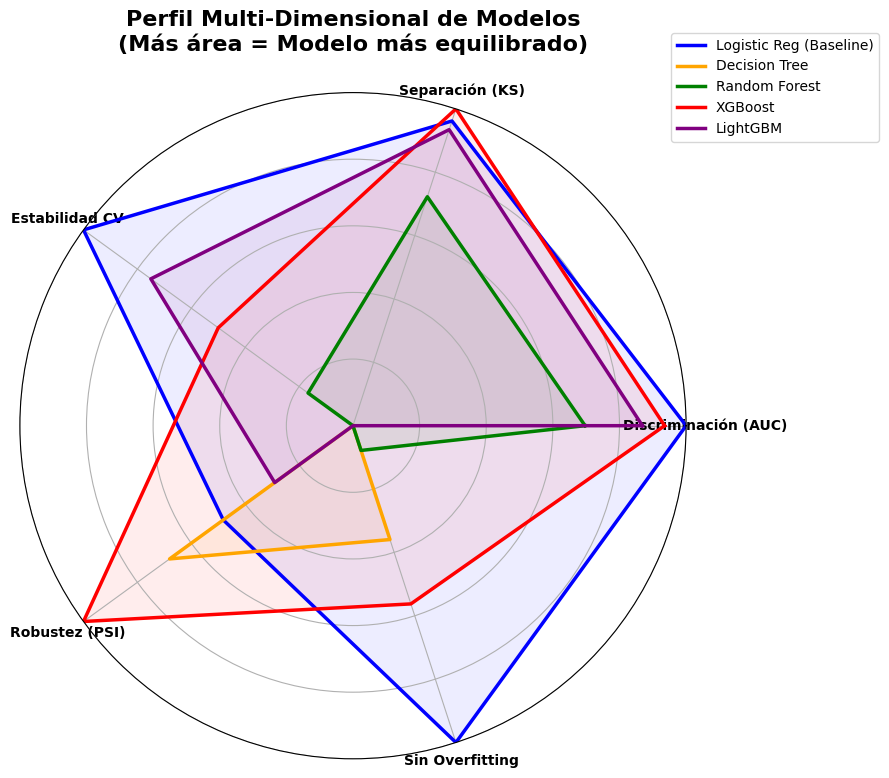

In [15]:
# 1. Preparación de datos para el Radar (Normalización)
radar_raw = pd.DataFrame({
    'Discriminación (AUC)': summary['AUC-ROC'],
    'Separación (KS)':      summary['KS'],
    'Estabilidad CV':       summary['CV Std'],
    'Robustez (PSI)':       summary['PSI'],
    'Sin Overfitting':      summary['Overfitting'],
}, index=summary.index)

# Normalización 0-1: Donde mayor es mejor
for col in ['Discriminación (AUC)', 'Separación (KS)']:
    c_min, c_max = radar_raw[col].min(), radar_raw[col].max()
    radar_raw[col] = (radar_raw[col] - c_min) / (c_max - c_min + 1e-9)

# Normalización 0-1: Donde menor es mejor (Invertimos para que "lejos del centro" sea bueno)
for col in ['Estabilidad CV', 'Robustez (PSI)', 'Sin Overfitting']:
    c_min, c_max = radar_raw[col].min(), radar_raw[col].max()
    radar_raw[col] = 1 - (radar_raw[col] - c_min) / (c_max - c_min + 1e-9)

# 2. Configuración de ángulos del gráfico
categories = list(radar_raw.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] 

# 3. Creación del gráfico
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for name, (model_obj, color) in MODELS.items():
    if name not in radar_raw.index: continue
    values = radar_raw.loc[name].tolist()
    values += values[:1]

    ax.plot(angles, values, color=color, linewidth=2.5, 
            linestyle='-', label=name)
    
    ax.fill(angles, values, color=color, alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticklabels([]) 
plt.title('Perfil Multi-Dimensional de Modelos\n(Más área = Modelo más equilibrado)', 
          size=16, fontweight='bold', pad=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

# **7. Selección del Modelo Final**

Siguiendo la práctica de bancos y reguladores (BIS BCBS Working Paper 14, 2005), la selección considera **4 ejes ponderados**:

| Eje | Peso | Criterio |
|-----|------|----------|
| **Discriminación** | 35% | AUC-ROC / Gini  |
| **Separación** | 25% | KS |
| **Estabilidad** | 20% | CV Std |
| **Similitud** | 20% | PSI |

> Para uso bajo IFRS 9 / Basilea, la calibración y estabilidad tienen peso regulatorio.

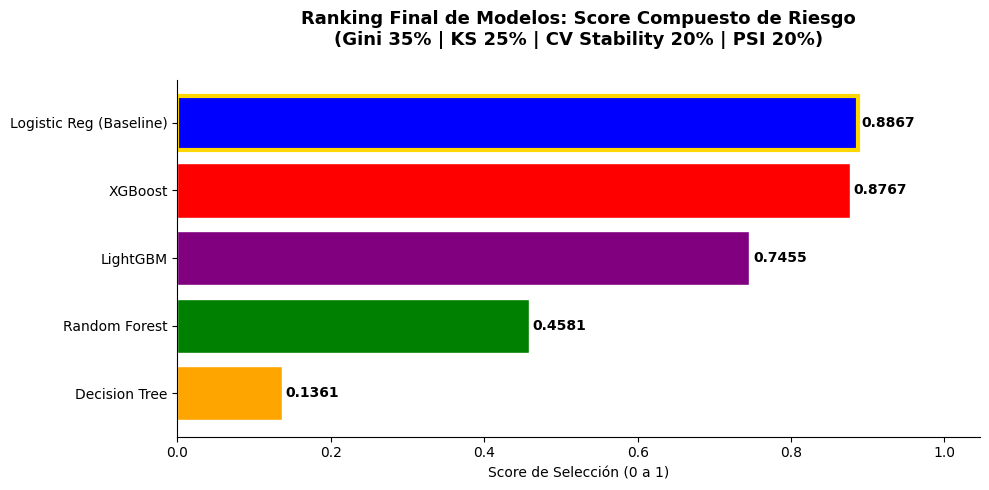

🏆 Modelo Recomendado: Logistic Reg (Baseline)


In [16]:
# 1. Definición de métricas para Credit Scoring
# Normalizamos: más alto es mejor
def normalize(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
# Invertimos: para métricas de error, donde menos es mejor
def invert(s): return 1 - normalize(s)

# --- LÓGICA DE NEGOCIO (PESOS) ---
# Gini (35%): El estándar para medir qué tan bien rankea clientes.
# KS (25%): Capacidad de separar Buenos de Malos en el punto de corte.
# Estabilidad CV (20%): Qué tanto varía el modelo en distintos trozos de datos.
# PSI (20%): Qué tan parecida es la población de Test a la de Train.

summary['Score Final'] = (
    normalize(summary['Gini'])   * 0.35 + 
    normalize(summary['KS'])     * 0.25 + 
    invert(summary['CV Std'])    * 0.20 + 
    invert(summary['PSI'])       * 0.20
)

# 2. Preparación para el gráfico
score_df = summary[['Score Final']].sort_values('Score Final', ascending=True)
winner = score_df['Score Final'].idxmax()

# 3. Gráfica de Ranking Final
fig, ax = plt.subplots(figsize=(10, 5))

# Usamos los colores definidos en tu diccionario MODELS
colors_bar = [MODELS.get(m, (None, 'gray'))[1] for m in score_df.index]

bars = ax.barh(score_df.index, score_df['Score Final'], 
               color=colors_bar, edgecolor='white', linewidth=1)

# Etiquetas de valor
for bar in bars:
    val = bar.get_width()
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

# Resaltar al ganador con estética "Premium"
winner_idx = list(score_df.index).index(winner)
bars[winner_idx].set_edgecolor('#FFD700') # Oro
bars[winner_idx].set_linewidth(3)

# Estética de reporte bancario
ax.set_title('Ranking Final de Modelos: Score Compuesto de Riesgo\n'
             f'(Gini 35% | KS 25% | CV Stability 20% | PSI 20%)', 
             fontweight='bold', fontsize=13, pad=25)
ax.set_xlabel('Score de Selección (0 a 1)', fontsize=10)
ax.set_xlim(0, score_df['Score Final'].max() * 1.18)

# Despine para limpieza visual
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print(f"🏆 Modelo Recomendado: {winner}")

**El Ganador Indiscutible: Logistic Regression (Baseline)**

Contra todo pronóstico inicial, el modelo más sencillo ha demostrado ser el más robusto para este conjunto de datos. 

- **Poder de Discriminación**: Lidera con un AUC-ROC de 0.7817 y un Gini de 0.5635. Supera ligeramente a XGBoost (0.7787), lo que indica que la relación entre las variables predictoras y el riesgo de impago es predominantemente lineal.

- **Estabilidad Superior**: Presenta la menor desviación estándar en Validación Cruzada (0.0057). Esto significa que el modelo es "constante"; no importa qué parte de los datos vea, su comportamiento no varía.

- **Eficiencia de Generalización**: Su Overfitting Ratio es prácticamente 1.002 (el más bajo). El modelo no ha memorizado el ruido del entrenamiento, sino que ha aprendido patrones reales que se repiten en el test.2. 

¿Por qué la Regresión Logística es mejor que XGBoost en este caso?
Técnicamente, hay tres razones clave para explicar por qué el "alumno básico" le ganó a los "especialistas": 
1. **Linealidad de los Atributos**: En riesgo financiero, muchas variables (como el nivel de ingresos o los días de mora) suelen tener una relación monótona y lineal con la probabilidad de default. La LR es imbatible explotando estas relaciones directas.
2. **Volumen y Calidad de Features**: Si las variables ya han pasado por un proceso de ingeniería previo (como el tratamiento de valores atípicos o transformaciones), se le "mastica" el trabajo a la LR. Los modelos de árboles brillan cuando hay interacciones ocultas y no lineales que la LR no puede ver; si esas interacciones no existen o son débiles, los árboles solo añaden complejidad innecesaria.
3. **Sesgo vs. Varianza**: Los modelos complejos (XGBoost/LightGBM) tienen una alta varianza (tienden al sobreajuste). La LR tiene un alto sesgo pero una varianza bajísima, lo que la hace extremadamente estable ante datos nuevos, un factor crítico en un entorno bancario.

- **Análisis Multi-Dimensional (Radar Chart)**: Al observar el gráfico de radar, la Regresión Logística (línea azul) cubre la mayor área total, especialmente en los ejes de Sin Overfitting y Estabilidad CV. XGBoost (Rojo) compite fuertemente en Robustez (PSI) y Separación (KS), pero flaquea en la consistencia de la validación cruzada comparado con la LR.Decision Tree (Naranja) es el modelo más débil, quedando rezagado en casi todas las dimensiones de discriminación.

- **Estabilidad de la Población (PSI)**: Todos los modelos presentan un estado "Stable" con valores de PSI extremadamente bajos (cercanos a 0.001 - 0.003).Interpretación: Esto garantiza que la distribución de riesgos que el modelo aprendió en el entrenamiento es idéntica a la que está viendo en el conjunto de prueba. No hay "Drift" poblacional, lo que da luz verde para una implementación segura.

- **Recomendación de Negocio**: Desde una perspectiva de Gobierno de Modelos y Riesgos, la recomendación es implementar la Regresión Logística por las siguientes razones:
  - Interpretabilidad (Explainability): Es un modelo de "caja blanca". Podemos explicar exactamente por qué se le denegó un crédito a un cliente basándonos en sus coeficientes. Esto es vital para cumplir con regulaciones financieras.
  - Facilidad de Implementación: Traducir una Regresión Logística a código de producción (o incluso a una tarjeta de puntuación en Excel/SQL) es infinitamente más sencillo y menos costoso que desplegar un objeto de XGBoost.
  - Robustez ante el ciclo económico: Al ser menos compleja, la LR tiende a degradarse más lentamente cuando las condiciones del mercado cambian ligeramente.